# EN3150 Assignment 03: Resource-Constrained Image Classification

This notebook compares standard and lightweight convolutional neural
networks for EuroSAT RGB land-cover classification.

- **Input:** A 64 × 64 RGB satellite image.
- **Target:** One of 10 land-cover classes.
- **Custom models:** A standard CNN and a depthwise-separable CNN.
- **Pretrained models:** MobileNetV2 and ShuffleNetV2.
- **Evaluation:** Classification performance, model size and computational cost.

## 1. Environment verification

We first check the active Python environment, package versions and
PyTorch GPU availability. This establishes the hardware and software
used for the experiments.

In [1]:
import sys
import platform
from importlib.metadata import version

import torch
import torchvision

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("Operating system:", platform.platform())

print("\nPackage versions:")
for package in [
    "torch",
    "torchvision",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "Pillow",
]:
    print(f"  {package}: {version(package)}")

print("\nGPU information:")
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

if device.type == "cuda":
    properties = torch.cuda.get_device_properties(0)
    print("GPU:", properties.name)
    print(f"Total GPU memory: {properties.total_memory / 1024**3:.2f} GiB")

# Verify that a small tensor operation works on the selected device.
x = torch.ones((2, 3), device=device)
print("\nDevice computation check:", (x * 2).sum().item())

Python executable: c:\Users\hrana\anaconda3\envs\ml_env_fixed\python.exe
Python version: 3.11.14
Operating system: Windows-10-10.0.26200-SP0

Package versions:
  torch: 2.5.1
  torchvision: 0.20.1
  numpy: 1.26.4
  pandas: 2.3.3
  scikit-learn: 1.8.0
  matplotlib: 3.10.9
  Pillow: 12.3.0

GPU information:
PyTorch CUDA build: 11.8
CUDA available: True
Selected device: cuda
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
Total GPU memory: 4.00 GiB

Device computation check: 12.0


## 2. Dataset location

I keep the original EuroSAT images in `data/raw/eurosat/2750`.
I use paths relative to the project folder so the notebook can run
on another computer without changing a personal file path.

In [2]:
from pathlib import Path

# I support running the notebook from the project folder or notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# I set the folders used to download and load the dataset.
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
ARCHIVE_PATH = RAW_DATA_DIR / "eurosat" / "EuroSAT.zip"
DATA_ROOT = RAW_DATA_DIR / "eurosat" / "2750"

print("Project folder:", PROJECT_ROOT)
print("Image folder:", DATA_ROOT)

Project folder: d:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN
Image folder: d:\2_ML PROJECTS\38. CNN_PR\EN3150-Assignment03-CNN\data\raw\eurosat\2750


### 2.1 Load the dataset

I downloaded the EuroSAT RGB archive through my browser.
I check its checksum before extracting it to confirm the download is complete.

I then load the original images without resizing or augmentation.

In [3]:
import hashlib
from zipfile import ZipFile
from torchvision.datasets import EuroSAT

if not ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        f"I need to place EuroSAT.zip here:\n{ARCHIVE_PATH}"
    )

# I check the archive against the checksum used by torchvision.
expected_md5 = "c8fa014336c82ac7804f0398fcb19387"

checksum = hashlib.md5()
with ARCHIVE_PATH.open("rb") as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b""):
        checksum.update(chunk)

if checksum.hexdigest() != expected_md5:
    raise ValueError("The checksum does not match. Download the archive again.")

print("Archive checksum verified.")

# I extract the images if the dataset folder is not already present.
if not DATA_ROOT.is_dir():
    with ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(ARCHIVE_PATH.parent)
    print("Dataset extracted.")

# I load the images without applying any transforms.
dataset = EuroSAT(
    root=str(RAW_DATA_DIR),
    download=False,
    transform=None,
)

CLASS_NAMES = dataset.classes

print("\nTotal images:", len(dataset))
print("Number of classes:", len(CLASS_NAMES))

print("\nClass labels:")
for class_name, label in dataset.class_to_idx.items():
    print(f"  {label}: {class_name}")

# I check the size, colour mode and label of one image.
image, label = dataset[0]

print("\nFirst image:")
print("Size (width, height):", image.size)
print("Colour mode:", image.mode)
print("Label:", label)
print("Class:", CLASS_NAMES[label])

Archive checksum verified.

Total images: 27000
Number of classes: 10

Class labels:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake

First image:
Size (width, height): (64, 64)
Colour mode: RGB
Label: 0
Class: AnnualCrop


## 3. Data exploration

### 3.1 Class distribution

I count the images in each class to check whether the dataset is balanced.
I also calculate each class's percentage of the total dataset.



,class_name,image_count,percentage
0,AnnualCrop,3000,11.11
1,Forest,3000,11.11
2,HerbaceousVegetation,3000,11.11
3,Highway,2500,9.26
4,Industrial,2500,9.26
5,Pasture,2000,7.41
6,PermanentCrop,2500,9.26
7,Residential,3000,11.11
8,River,2500,9.26
9,SeaLake,3000,11.11


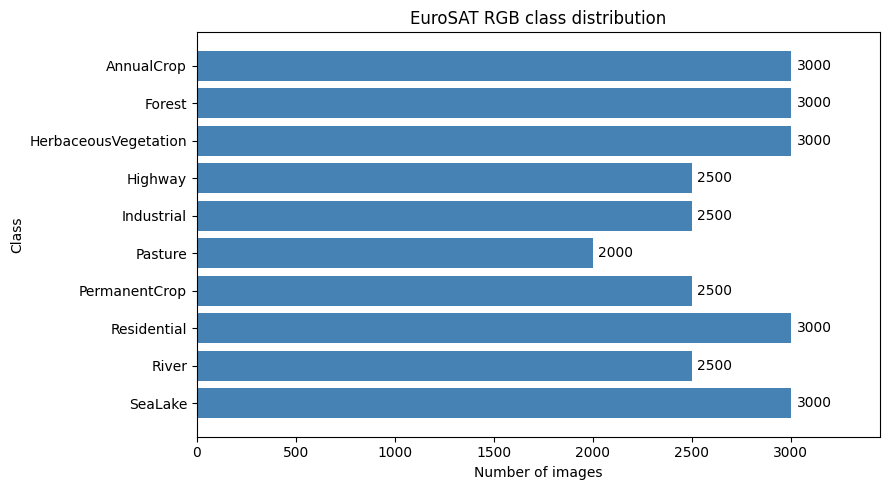

Largest class: 3,000 images
Smallest class: 2,000 images
Largest-to-smallest ratio: 1.50


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# I create one row for each image and its class label.
image_df = pd.DataFrame(dataset.samples, columns=["path", "label"])
image_df["class_name"] = image_df["label"].map(
    dict(enumerate(CLASS_NAMES))
)

# I count the images in each class.
class_counts = (
    image_df.groupby("class_name")
    .size()
    .reindex(CLASS_NAMES)
    .rename("image_count")
    .reset_index()
)

class_counts["percentage"] = (
    100 * class_counts["image_count"] / len(image_df)
).round(2)

display(class_counts)

# I plot the counts to compare the classes.
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    class_counts["class_name"],
    class_counts["image_count"],
    color="steelblue",
)

ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of images")
ax.set_ylabel("Class")
ax.set_title("EuroSAT RGB class distribution")
ax.set_xlim(0, class_counts["image_count"].max() * 1.15)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

largest = class_counts["image_count"].max()
smallest = class_counts["image_count"].min()

print(f"Largest class: {largest:,} images")
print(f"Smallest class: {smallest:,} images")
print(f"Largest-to-smallest ratio: {largest / smallest:.2f}")

The class sizes range from 2,000 to 3,000 images. Pasture is the smallest
class, and the largest-to-smallest ratio is 1.5.

I use a stratified split to keep similar class proportions in the training,
validation and test sets. I start without class weighting and later check
per-class precision and recall to see whether smaller classes perform worse.

### 3.2 Sample images

I display three images from each class to inspect their colours, textures
and shapes. I use a fixed random seed so the same examples appear when
I rerun this cell.

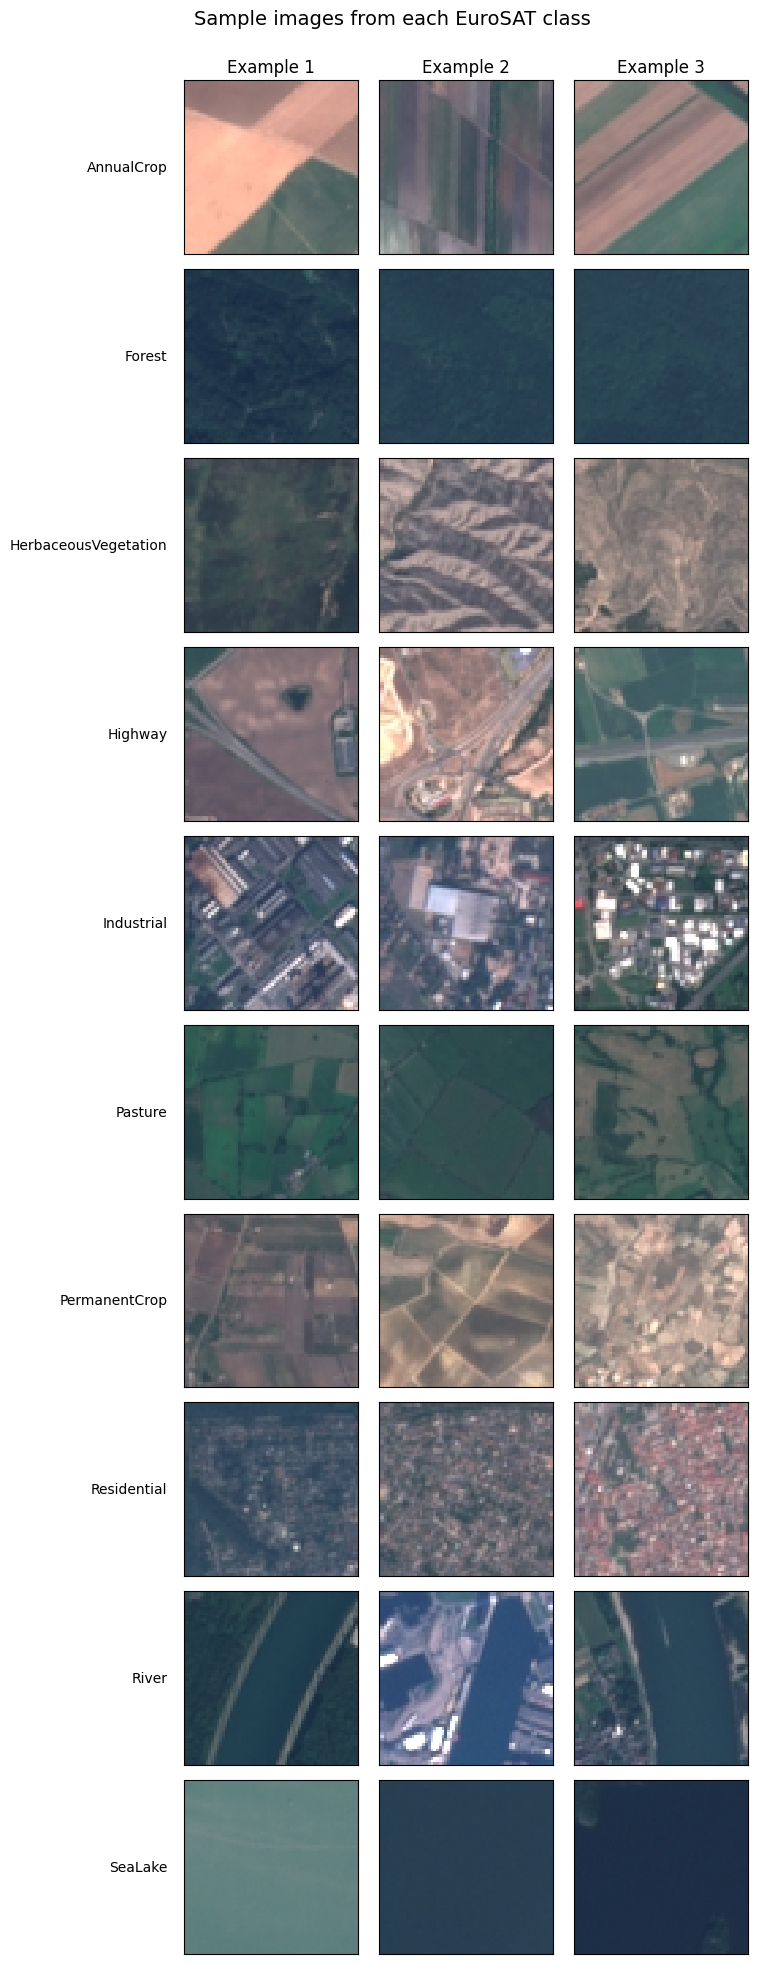

In [6]:
from PIL import Image

# I use a fixed seed to select the same examples each time.
SEED = 42
rng = np.random.default_rng(SEED)
samples_per_class = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    samples_per_class,
    figsize=(8, 20),
)

for label, class_name in enumerate(CLASS_NAMES):
    class_indices = image_df.index[
        image_df["label"] == label
    ].to_numpy()

    selected_indices = rng.choice(
        class_indices,
        size=samples_per_class,
        replace=False,
    )

    for column, index in enumerate(selected_indices):
        image_path = image_df.loc[index, "path"]

        with Image.open(image_path) as image:
            axes[label, column].imshow(image, interpolation="nearest")

        axes[label, column].set_xticks([])
        axes[label, column].set_yticks([])

        if column == 0:
            axes[label, column].set_ylabel(
                class_name,
                rotation=0,
                ha="right",
                va="center",
                labelpad=12,
            )

        if label == 0:
            axes[label, column].set_title(f"Example {column + 1}")

fig.suptitle("Sample images from each EuroSAT class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 3.3 Image quality checks

I check that every image can be opened and fully read.
I also check the original image dimensions and colour modes.

This helps me find damaged files or unexpected image formats before
splitting the dataset.

In [7]:
from tqdm.auto import tqdm

image_checks = []

# I read every image and record its original size and colour mode.
for image_path in tqdm(image_df["path"], desc="Checking images"):
    record = {
        "path": image_path,
        "width": None,
        "height": None,
        "mode": None,
        "error": None,
    }

    try:
        with Image.open(image_path) as image:
            image.load()
            record["width"], record["height"] = image.size
            record["mode"] = image.mode

    except (OSError, ValueError) as error:
        record["error"] = str(error)

    image_checks.append(record)

quality_df = pd.DataFrame(image_checks)
valid_images = quality_df[quality_df["error"].isna()]
unreadable_images = quality_df[quality_df["error"].notna()]

print("Images checked:", len(quality_df))
print("Readable images:", len(valid_images))
print("Unreadable images:", len(unreadable_images))

print("\nImage sizes and colour modes:")
display(
    valid_images.groupby(["width", "height", "mode"])
    .size()
    .reset_index(name="image_count")
)

unexpected_images = valid_images[
    (valid_images["width"] != 64)
    | (valid_images["height"] != 64)
    | (valid_images["mode"] != "RGB")
]

print("Images with unexpected size or colour mode:", len(unexpected_images))

if not unreadable_images.empty:
    display(unreadable_images.head(10))

if not unexpected_images.empty:
    display(unexpected_images.head(10))

Checking images:   0%|          | 0/27000 [00:00<?, ?it/s]

Images checked: 27000
Readable images: 27000
Unreadable images: 0

Image sizes and colour modes:


,width,height,mode,image_count
0,64,64,RGB,27000


Images with unexpected size or colour mode: 0


All 27,000 images are readable and have a resolution of 64 × 64 pixels
with three RGB channels. I found no unreadable images or unexpected formats,
so no resizing is needed to meet the assignment's resolution limit.

From the displayed examples, I find some classes easier to recognise than
others. HerbaceousVegetation is less clear to me. I will later use the
confusion matrix to check which classes are difficult for the models.